In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# MRLS

# dados de diabetes
diabetes = load_diabetes()
# BMI (índice de massa corporal)
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
print(f"Amostras: {X.shape[0]} | Features: {X.shape[1]}")

Amostras: 442 | Features: 1


In [4]:
X[:5]*998.577, y[:5]

(array([[ 61.60841282],
        [-51.40081365],
        [ 44.38795926],
        [-11.5785148 ],
        [-36.33291679]]),
 array([151.,  75., 141., 206., 135.]))

In [5]:
_X = np.array([[1,1], [1,2], [2,2], [2,3]])
_y = np.dot(_X, np.array([1, 2])) + 3
_X, _y

(array([[1, 1],
        [1, 2],
        [2, 2],
        [2, 3]]),
 array([ 6,  8,  9, 11]))

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [7]:
print("Coeficiente angular (alpha):", model.coef_[0])
print("Intercepto (beta):", model.intercept_)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

Coeficiente angular (alpha): 998.5776891375598
Intercepto (beta): 152.00335421448167
MSE: 4061.8259284949268
RMSE: 63.73245584860925


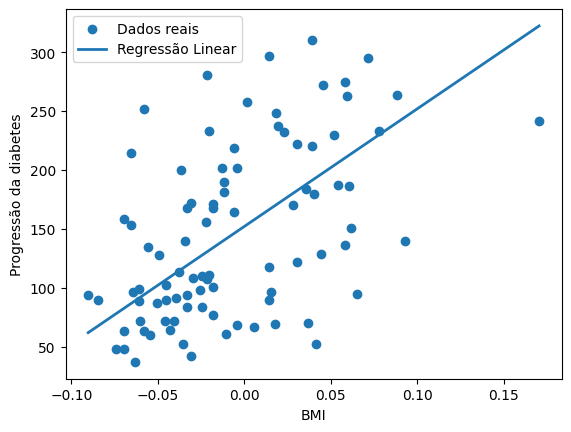

In [8]:
plt.scatter(X_test, y_test, label="Dados reais")

# ordenar para desenhar reta corretamente
idx = np.argsort(X_test[:, 0])

plt.plot(
    X_test[idx],
    y_pred[idx],
    linewidth=2,
    label="Regressão Linear"
)

plt.xlabel("BMI")
plt.ylabel("Progressão da diabetes")
plt.legend()

plt.show()

In [9]:
# MRLM
# dados de preço de casas na California
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler


dados = fetch_california_housing()
X, y = dados.data, dados.target  

print(f"Amostras: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Features: {dados.feature_names}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# normalizar --> boa prática com múltiplas características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Amostras: 20640 | Features: 8
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']



In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.4f}")

MSE:  0.5559


In [14]:
print("Coeficientes (alphas):")
for nome, coef in zip(dados.feature_names, model.coef_):
    print(f"  {nome:12s}: {coef:+.4f}")

Coeficientes (alphas):
  MedInc      : +0.8544
  HouseAge    : +0.1225
  AveRooms    : -0.2944
  AveBedrms   : +0.3393
  Population  : -0.0023
  AveOccup    : -0.0408
  Latitude    : -0.8969
  Longitude   : -0.8698


In [15]:
print("Intercepto (beta):", model.intercept_)

Intercepto (beta): 2.071946937378619


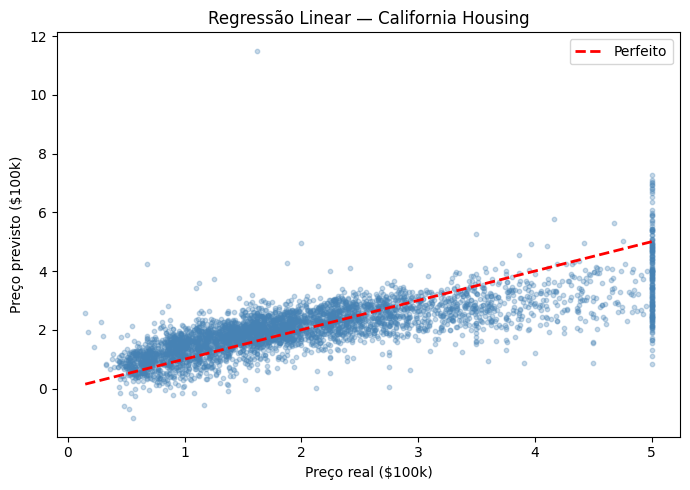

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", linewidth=2, label="Perfeito")
plt.xlabel("Preço real ($100k)")
plt.ylabel("Preço previsto ($100k)")
plt.title("Regressão Linear — California Housing")
plt.legend()e
plt.tight_layout()
plt.show()